[nltk_data] Downloading package stopwords to C:\Users\M S
[nltk_data]     I\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Accuracy with TF-IDF: 0.9641062455132807

✅ Classification Report (TF-IDF):
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1202
        spam       0.99      0.74      0.85       191

    accuracy                           0.96      1393
   macro avg       0.98      0.87      0.91      1393
weighted avg       0.97      0.96      0.96      1393



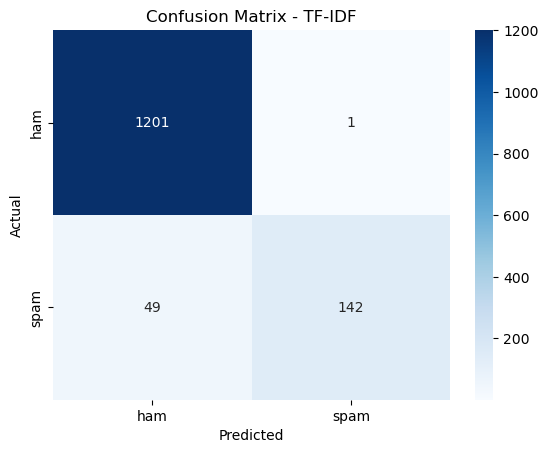


🔁 Accuracy with CountVectorizer: 0.9763101220387652

🔁 Classification Report (CountVectorizer):
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1202
        spam       0.91      0.92      0.91       191

    accuracy                           0.98      1393
   macro avg       0.95      0.95      0.95      1393
weighted avg       0.98      0.98      0.98      1393



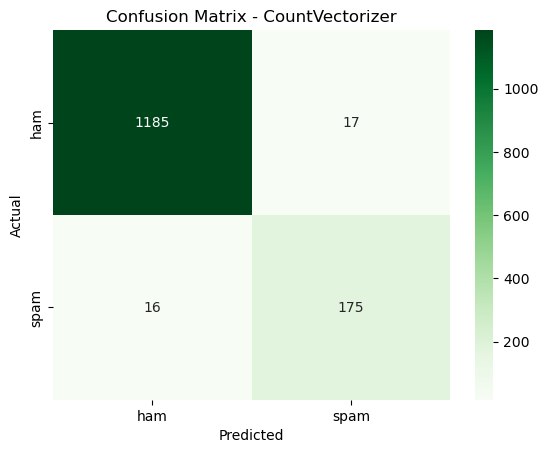

In [1]:
# ================================================
# 🔗 Dataset Info: SMS Spam Collection Dataset
# Source: UCI Machine Learning Repository
# Download Link: https://archive.ics.uci.edu/dataset/228/sms%2Bspam%2Bcollection
#
# 📄 Description:
# - Contains 5,574 real SMS messages in English
# - Each message is labeled as:
#   • 'ham'  – legitimate/normal message
#   • 'spam' – unwanted promotional or fraudulent message
# - Format: A CSV with two columns:
#   • v1 = label ('ham' or 'spam')
#   • v2 = the actual message text
# ================================================

# Step 1: Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load dataset and select relevant columns
data = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
data.columns = ['label', 'text']  # Rename for clarity

# -----------------------------------------------------
# ✅ TODO 1: Preprocess the text data
# - Converts text to lowercase
# - Removes punctuation and symbols
# - Removes stopwords (e.g., "the", "is", etc.)
# - Applies stemming (e.g., "running" → "run")
# Improves generalization by reducing noise
# -----------------------------------------------------
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = re.sub(r'\W', ' ', text.lower())
    return ' '.join([stemmer.stem(word) for word in text.split() if word not in stop_words])

data['text'] = data['text'].apply(preprocess)

# Step 3: Convert messages to TF-IDF numeric features
# TF-IDF (Term Frequency-Inverse Document Frequency):
# - TF: frequency of a word in a message
# - IDF: downweights common words across all messages
# Helps the model focus on informative words for classification
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['text'])  # Sparse matrix of TF-IDF values
y = data['label']  # Target classes

# Step 4: Train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 5: Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 6: Predict on test set
y_pred = model.predict(X_test)

# Step 7: Evaluation
print("✅ Accuracy with TF-IDF:", accuracy_score(y_test, y_pred))
print("\n✅ Classification Report (TF-IDF):\n", classification_report(y_test, y_pred))

# Step 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix - TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------------------
# ✅ TODO 2: Try CountVectorizer instead of TF-IDF
# CountVectorizer:
# - Creates a matrix of raw word counts (Bag of Words)
# - No normalization or frequency weighting
# Use this to compare results with TF-IDF
# --------------------------------------------------------
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(data['text'])

X_train_c, X_test_c, y_train, y_test = train_test_split(X_count, y, test_size=0.25, random_state=42)

model_c = MultinomialNB()
model_c.fit(X_train_c, y_train)

y_pred_c = model_c.predict(X_test_c)

print("\n🔁 Accuracy with CountVectorizer:", accuracy_score(y_test, y_pred_c))
print("\n🔁 Classification Report (CountVectorizer):\n", classification_report(y_test, y_pred_c))

cm_count = confusion_matrix(y_test, y_pred_c, labels=["ham", "spam"])
sns.heatmap(cm_count, annot=True, fmt="d", cmap="Greens", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Confusion Matrix - CountVectorizer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Analysis Questions

Accuracy Comparison and Reflection 
1. What was the accuracy for each of the following settings?

    TF-IDF without preprocessing: 0.9576

    TF-IDF with preprocessing: 0.9641

    CountVectorizer without preprocessing: 0.9763

    CountVectorizer with preprocessing: 0.9763

2. Which method achieved the highest accuracy? Why do you think that is?

The highest accuracy was achieved using CountVectorizer, which gave an accuracy of 0.9763.
This is because CountVectorizer captures the frequency of words directly, which is very effective for spam detection since spam messages often contain repeated keywords such as promotional terms. These repeated patterns are easier for the model to learn compared to TF-IDF, which reduces the importance of frequently occurring words.

3. Which method performed the worst, and why might that be?

The worst-performing method was TF-IDF without preprocessing, with an accuracy of 0.9576.
This may be due to the presence of noise such as punctuation, stopwords, and inconsistent word forms. Without preprocessing, the model may learn less meaningful patterns. Additionally, TF-IDF reduces the importance of frequently occurring words, which may negatively impact spam detection where repeated words are important indicators.